In [1]:
# 1. THƯ VIỆN XỬ LÝ VÀ TÍNH TOÁN DỮ LIỆU
import pandas as pd  # Thao tác với dữ liệu dạng bảng (DataFrame): đọc/ghi file CSV, xử lý cột, dòng, giá trị khuyết
import numpy as np  # Tính toán số học mảng nhiều chiều (array), ma trận và đại số tuyến tính

from sklearn.linear_model import LogisticRegression
# 2. THƯ VIỆN XÂY DỰNG MẠNG NƠ-RON (DEEP LEARNING)
import tensorflow as tf  # Nền tảng lõi: tính toán đạo hàm tự động (gradient) và điều phối phần cứng GPU/


from tensorflow.keras import (
    layers,  # Chứa các lớp nơ-ron (Dense, Dropout, Conv2D, v.v.)
    models,  # Đóng gói kiến trúc các lớp thành mô hình hoàn chỉnh (Model, Sequential)
    Input,  # Khai báo kích thước/hình dạng (shape) của dữ liệu đầu vào cho mạng
)


# 3. THƯ VIỆN TIỀN XỬ LÝ VÀ ĐÁNH GIÁ (SCIKIT-LEARN)
from sklearn.model_selection import (
    train_test_split,  # Tách tập dữ liệu thành tập học (Train) và tập kiểm thử (Test)
)
from sklearn.preprocessing import (
    StandardScaler,  # Chuẩn hóa dữ liệu về phân phối chuẩn (mean = 0, variance = 1) giúp mô hình hội tụ tốt hơn
)
from sklearn.metrics import (
    roc_auc_score,  # Đánh giá hiệu năng bài toán phân loại nhị phân dựa trên diện tích dưới đường cong ROC
classification_report,
confusion_matrix, 
accuracy_score
)
print("hoan thanh ")

hoan thanh 


In [2]:
# Xem chính xác đường dẫn file csv của bạn trên Kaggle
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/nambo2004/benh-vien-a-private/private_A_1000_dong.csv
/kaggle/input/datasets/nambo2004/share-feature/shared_data_11000_dong.csv
/kaggle/input/datasets/nambo2004/benh-vien-b-private/private_B_10000_dong.csv
/kaggle/input/datasets/nambo2004/labels/labels_11000_dong.csv


In [ ]:
# xây dựng model hồi quy logistic Dự Đoán Nguy Cơ Tử Vong Trong Vòng 1 Năm Dựa Trên Dữ Liệu Hồi Sức 24 Giờ Đầu Nhập Viện cho bệnh viện A

In [6]:
# Cell 1  Nạp Dữ Liệu & Ghép Bảng Hoàn Chỉnh Cho Bệnh Viện A (1,000 ca)
import os
import pandas as pd
import numpy as np

# 1. Đường dẫn các file đã tải lên Kaggle của bạn
path_priv_a = '/kaggle/input/datasets/nambo2004/benh-vien-a-private/private_A_1000_dong.csv'
path_shared = '/kaggle/input/datasets/nambo2004/share-feature/shared_data_11000_dong.csv'
path_labels = '/kaggle/input/datasets/nambo2004/labels/labels_11000_dong.csv'

print("⏳ Đang nạp dữ liệu...")
df_priv_a = pd.read_csv(path_priv_a)
df_shared = pd.read_csv(path_shared)
df_labels = pd.read_csv(path_labels)

# 2. Ghép 3 bảng lại thành 1 bảng duy nhất cho Bệnh viện A (Inner Join theo hadm_id)
df_A_full = df_shared.merge(df_priv_a, on='hadm_id', how='inner') \
                     .merge(df_labels, on='hadm_id', how='inner')

# Cho phép hiển thị toàn bộ 25 cột
pd.set_option('display.max_columns', None)

print("=" * 60)
print(f"🎉 ĐÃ TRÍCH XUẤT THÀNH CÔNG BẢNG DỮ LIỆU BV A: {df_A_full.shape}")
print(f"• Số lượng bệnh nhân: {len(df_A_full):,} người")
print(f"• Tổng số cột: {df_A_full.shape[1]} cột (1 cột hadm_id + 23 đặc trưng + 1 cột nhãn mortality)")
print("=" * 60)

# Hiển thị 5 dòng đầu tiên
df_A_full.head()


⏳ Đang nạp dữ liệu...
🎉 ĐÃ TRÍCH XUẤT THÀNH CÔNG BẢNG DỮ LIỆU BV A: (1000, 25)
• Số lượng bệnh nhân: 1,000 người
• Tổng số cột: 25 cột (1 cột hadm_id + 23 đặc trưng + 1 cột nhãn mortality)


,hadm_id,gender,age,cardiovascular,neurological,pulmonary,diabetes,renal,liver,cancer,mental_substance,hem_metabolic,autoimmune,gcs_min,weight_kg,heart_rate_mean,sbp_mean,dbp_mean,mbp_mean,resp_rate_mean,temp_c_mean,spo2_mean,fio2_max,urine_output_24h,mortality
0,22600049,0,61,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,80.2,63.241379,121.800000,55.933333,73.466667,17.666667,36.650794,99.516129,50.0,3000.0,0
1,26774271,0,67,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,55.5,78.769231,107.814815,50.111111,68.222222,14.692308,36.444444,98.846154,100.0,3615.0,0
2,23181353,0,79,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,80.2,68.291667,123.212121,65.939394,90.666667,16.041667,37.629630,98.875000,40.0,1098.0,0
3,21453672,1,70,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,80.2,68.576923,101.741935,52.580645,68.129032,17.846154,36.896825,99.916667,100.0,3905.0,0
4,29740189,0,67,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,80.2,70.480000,110.923077,53.384615,70.923077,13.760000,36.777778,96.961538,100.0,4025.0,0


In [5]:
# Cell 2: Thống kê dữ liệu
print("=" * 60)
print("📊 BÁO CÁO THỐNG KÊ DỮ LIỆU BỆNH VIỆN A:")
print("=" * 60)

# 1. Kiểm tra ô khuyết (Missing Values)
total_null = df_A_full.isna().sum().sum()
print(f"1. Tổng số ô NULL trên toàn bảng: {total_null} ô (Chuẩn 100% không ô khuyết)")

# 2. Phân bố nhãn tử vong (mortality)
counts = df_A_full['mortality'].value_counts()
pcts = df_A_full['mortality'].value_counts(normalize=True) * 100
print("\n2. Phân bố nhãn mục tiêu (mortality_1yr):")
print(f"   • Sống sót (0): {counts[0]:,} ca ({pcts[0]:.2f}%)")
print(f"   • Tử vong  (1): {counts[1]:,} ca ({pcts[1]:.2f}%)")

# 3. Danh sách các cột theo nhóm
cols_shared = [c for c in df_shared.columns if c != 'hadm_id']
cols_priv_a = [c for c in df_priv_a.columns if c != 'hadm_id']
print(f"\n3. Cơ cấu các cột đặc trưng:")
print(f"   • 14 Đặc trưng Chung ({len(cols_shared)} cột): {cols_shared}")
print(f"   • 9 Sinh hiệu Riêng A ({len(cols_priv_a)} cột): {cols_priv_a}")




📊 BÁO CÁO THỐNG KÊ DỮ LIỆU BỆNH VIỆN A:
1. Tổng số ô NULL trên toàn bảng: 0 ô (Chuẩn 100% không ô khuyết)

2. Phân bố nhãn mục tiêu (mortality_1yr):
   • Sống sót (0): 792 ca (79.20%)
   • Tử vong  (1): 208 ca (20.80%)

3. Cơ cấu các cột đặc trưng:
   • 14 Đặc trưng Chung (14 cột): ['gender', 'age', 'cardiovascular', 'neurological', 'pulmonary', 'diabetes', 'renal', 'liver', 'cancer', 'mental_substance', 'hem_metabolic', 'autoimmune', 'gcs_min', 'weight_kg']
   • 9 Sinh hiệu Riêng A (9 cột): ['heart_rate_mean', 'sbp_mean', 'dbp_mean', 'mbp_mean', 'resp_rate_mean', 'temp_c_mean', 'spo2_mean', 'fio2_max', 'urine_output_24h']


In [9]:
# Cell 3 Chia Tập Train (80%) và Test (20%)
from sklearn.model_selection import train_test_split

# 1. Tách ma trận đặc trưng X (23 cột) và nhãn y (1 cột)
feature_cols = [c for c in df_A_full.columns if c not in ['hadm_id', 'mortality']]
X_A = df_A_full[feature_cols].copy()
y_A = df_A_full['mortality'].copy()

# 2. Chia tập Train (80%) và Test (20%) có phân tầng (stratify) chuẩn tác giả
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(
    X_A, y_A, 
    test_size=0.20, 
    random_state=42, 
    stratify=y_A
)

print("=" * 60)
print("🎉 ĐÃ CHIA XONG TẬP TRAIN/TEST CHO BỆNH VIỆN A (80% - 20%):")
print(f"• Tập TRAIN (Huấn luyện): {len(X_train_A)} ca | Tử vong: {y_train_A.sum()} ({y_train_A.mean()*100:.2f}%)")
print(f"• Tập TEST  (Kiểm định) : {len(X_test_A)} ca | Tử vong: {y_test_A.sum()} ({y_test_A.mean()*100:.2f}%)")
print(f"• Số chiều đặc trưng     : {X_train_A.shape[1]} cột")
print("=" * 60)


🎉 ĐÃ CHIA XONG TẬP TRAIN/TEST CHO BỆNH VIỆN A (80% - 20%):
• Tập TRAIN (Huấn luyện): 800 ca | Tử vong: 166 (20.75%)
• Tập TEST  (Kiểm định) : 200 ca | Tử vong: 42 (21.00%)
• Số chiều đặc trưng     : 23 cột


In [10]:
# CELL 4: Chuẩn Hóa Dữ Liệu (StandardScaler)
# Tại sao bắt buộc phải chuẩn hóa đối với Hồi quy Logistic:
# Các biến số có đơn vị rất lệch nhau (ví dụ: Nước tiểu đo hàng nghìn mL, SpO2 từ 50-100%, Bệnh nền chỉ là 0 và 1).
# Chuẩn hóa đưa tất cả về cùng phân phối (trung bình = 0, phương sai = 1), 
# giúp thuật toán hội tụ nhanh và cho phép so sánh trực tiếp trọng số của các biến sau khi huấn luyện.
# Nguyên tắc chống rò rỉ (Data Leakage): Chỉ dùng fit trên tập Train, sau đó lấy thước đo đó để transform cho tập Val và Test.

from sklearn.preprocessing import StandardScaler

# Chuẩn hóa dữ liệu về phân phối chuẩn (Mean = 0, Std = 1)
scaler = StandardScaler()

# Fit trên tập Train, sau đó Transform trên cả Train và Test
X_train_scaled = scaler.fit_transform(X_train_A)
X_test_scaled  = scaler.transform(X_test_A)

print("✅ Đã chuẩn hóa dữ liệu thành công:")
print(f"• X_train_scaled: {X_train_scaled.shape}")
print(f"• X_test_scaled : {X_test_scaled.shape}")



✅ Đã chuẩn hóa dữ liệu thành công:
• X_train_scaled: (800, 23)
• X_test_scaled : (200, 23)


In [11]:
# CELL 5: Huấn Luyện Hồi Quy Logistic Bằng GridSearchCV (5-Fold)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Khởi tạo mô hình hồi quy Logistic với class_weight='balanced'
log_reg_balanced_A = LogisticRegression(
    class_weight='balanced', 
    solver='liblinear', 
    random_state=42
)

# 2. Thiết lập lưới tham số cần tinh chỉnh
param_grid = {
    'C': [0.01, 0.1, 1, 10],            # Độ mạnh của Regularization
    'penalty': ['l1', 'l2']             # Điều chuẩn L1 (Lasso) hoặc L2 (Ridge)
}

# 3. GridSearchCV với 5-Fold Cross-Validation chuẩn tác giả
grid_search_bal = GridSearchCV(
    estimator=log_reg_balanced_A,
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# 4. Huấn luyện tìm mô hình tốt nhất
print("🚀 Đang chạy 5-Fold Cross Validation tìm tham số tối ưu...")
grid_search_bal.fit(X_train_scaled, y_train_A)

# 5. Lấy ra mô hình tốt nhất
best_log_reg_A = grid_search_bal.best_estimator_
print("\n" + "=" * 60)
print(f"🏆 Tham số tốt nhất tìm được: {grid_search_bal.best_params_}")
print(f"🏆 Điểm ROC-AUC trung bình qua 5 Folds: {grid_search_bal.best_score_:.4f}")
print("=" * 60)


🚀 Đang chạy 5-Fold Cross Validation tìm tham số tối ưu...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

🏆 Tham số tốt nhất tìm được: {'C': 1, 'penalty': 'l1'}
🏆 Điểm ROC-AUC trung bình qua 5 Folds: 0.7789


In [12]:
# CELL 6: Dự Đoán Trên Tập Test & Hiển Thị Kết Quả Từng Bệnh Nhân
import pandas as pd
import numpy as np

# 1. TIẾN HÀNH DỰ ĐOÁN TRÊN TẬP TEST (200 CA ĐỘC LẬP)
y_test_pred  = best_log_reg_A.predict(X_test_scaled)                 # Nhãn dự đoán (0 hoặc 1)
y_test_proba = best_log_reg_A.predict_proba(X_test_scaled)[:, 1]    # Xác suất tử vong (0.0 đến 1.0)

# 2. TẠO BẢNG SO SÁNH KẾT QUẢ CHI TIẾT
df_results = pd.DataFrame({
    'hadm_id': df_A_full.loc[X_test_A.index, 'hadm_id'].values,
    'Thực tế': y_test_A.values,
    'AI Dự đoán': y_test_pred,
    'Xác suất Tử vong': (y_test_proba * 100).round(2)
})

# Đổi số 0/1 thành chữ cho dễ đọc
df_results['Kết quả Thực tế'] = df_results['Thực tế'].map({0: 'Sống sót (0)', 1: 'Tử vong (1)'})
df_results['Kết luận của AI'] = df_results['AI Dự đoán'].map({0: 'Sống sót (0)', 1: 'Tử vong (1)'})

# Đánh giá đúng hay sai
df_results['Đánh giá'] = np.where(df_results['Thực tế'] == df_results['AI Dự đoán'], '✅ Đúng', '❌ Sai')

# Sắp xếp lại thứ tự cột cho đẹp
cols_display = ['hadm_id', 'Kết quả Thực tế', 'Kết luận của AI', 'Xác suất Tử vong', 'Đánh giá']
df_display = df_results[cols_display]

print("=" * 80)
print(f"🎯 KẾT QUẢ DỰ ĐOÁN TRÊN TẬP TEST ({len(df_display)} BỆNH NHÂN):")
so_ca_dung = (df_results['Thực tế'] == df_results['AI Dự đoán']).sum()
print(f"• Số ca AI dự đoán ĐÚNG: {so_ca_dung} / {len(df_display)} ca (Độ chính xác: {so_ca_dung/len(df_display)*100:.2f}%)")
print(f"• Số ca AI dự đoán SAI : {len(df_display) - so_ca_dung} / {len(df_display)} ca")
print("=" * 80)

# 3. HIỂN THỊ 15 BỆNH NHÂN ĐẦU TIÊN
print("\n📋 DANH SÁCH 15 BỆNH NHÂN ĐẦU TIÊN TRONG TẬP TEST:")
display(df_display.head(15))


🎯 KẾT QUẢ DỰ ĐOÁN TRÊN TẬP TEST (200 BỆNH NHÂN):
• Số ca AI dự đoán ĐÚNG: 144 / 200 ca (Độ chính xác: 72.00%)
• Số ca AI dự đoán SAI : 56 / 200 ca

📋 DANH SÁCH 15 BỆNH NHÂN ĐẦU TIÊN TRONG TẬP TEST:


,hadm_id,Kết quả Thực tế,Kết luận của AI,Xác suất Tử vong,Đánh giá
0,22902895,Sống sót (0),Sống sót (0),46.12,✅ Đúng
1,28331848,Sống sót (0),Sống sót (0),42.88,✅ Đúng
2,22072725,Sống sót (0),Tử vong (1),66.38,❌ Sai
3,29050348,Sống sót (0),Sống sót (0),25.93,✅ Đúng
4,24190230,Sống sót (0),Sống sót (0),21.23,✅ Đúng
5,23102771,Sống sót (0),Sống sót (0),19.33,✅ Đúng
6,21913898,Sống sót (0),Sống sót (0),26.28,✅ Đúng
7,28329903,Sống sót (0),Sống sót (0),17.13,✅ Đúng
8,28287265,Sống sót (0),Tử vong (1),56.74,❌ Sai
9,26934346,Tử vong (1),Tử vong (1),88.64,✅ Đúng


📊 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH BASELINE LOGISTIC BỆNH VIỆN A:
👉 Điểm ROC - AUC Score: 0.7815

Ma trận nhầm lẫn (Confusion Matrix):
[[114  44]
 [ 12  30]]

Bảng chi tiết phân loại (Classification Report):
              precision    recall  f1-score   support

    Sống (0)       0.90      0.72      0.80       158
 Tử vong (1)       0.41      0.71      0.52        42

    accuracy                           0.72       200
   macro avg       0.66      0.72      0.66       200
weighted avg       0.80      0.72      0.74       200



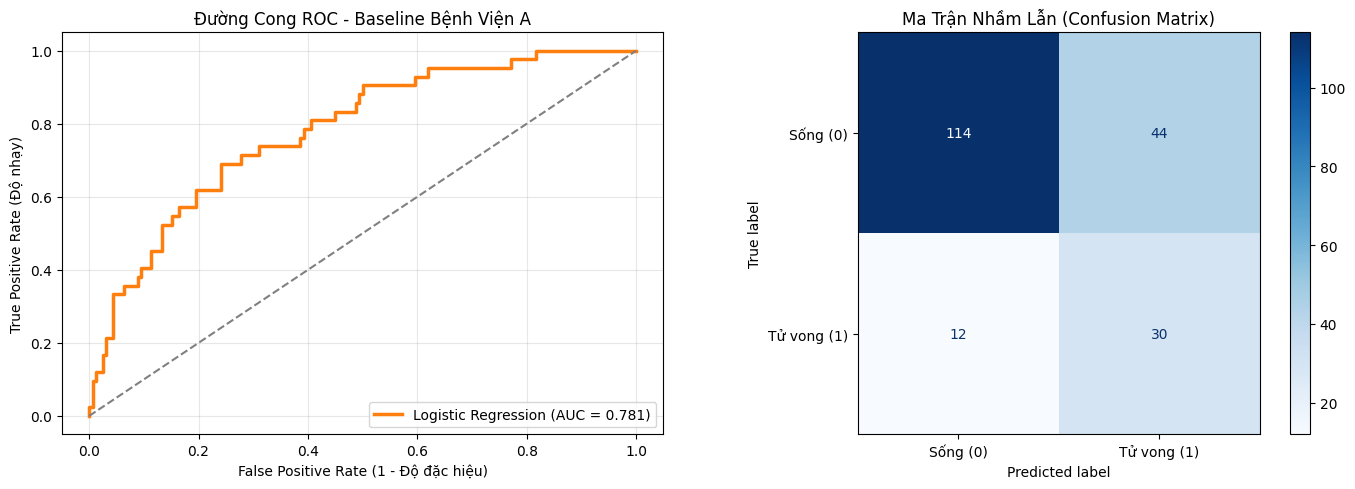

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

# 1. Dự đoán trên tập Test (200 ca độc lập)
y_pred_bal  = best_log_reg_A.predict(X_test_scaled)
y_proba_bal = best_log_reg_A.predict_proba(X_test_scaled)[:, 1]

# 2. Tính ROC-AUC
fpr, tpr, _ = roc_curve(y_test_A, y_proba_bal)
test_auc = auc(fpr, tpr)

print("=" * 60)
print("📊 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH BASELINE LOGISTIC BỆNH VIỆN A:")
print(f"👉 Điểm ROC - AUC Score: {test_auc:.4f}")
print("=" * 60)

print("\nMa trận nhầm lẫn (Confusion Matrix):")
print(confusion_matrix(y_test_A, y_pred_bal))

print("\nBảng chi tiết phân loại (Classification Report):")
print(classification_report(y_test_A, y_pred_bal, target_names=['Sống (0)', 'Tử vong (1)']))

# 3. Vẽ biểu đồ ROC Curve và Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ ROC Curve
axes[0].plot(fpr, tpr, color='#ff7f0e', lw=2.5, label=f'Logistic Regression (AUC = {test_auc:.3f})')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5)
axes[0].set_xlabel('False Positive Rate (1 - Độ đặc hiệu)')
axes[0].set_ylabel('True Positive Rate (Độ nhạy)')
axes[0].set_title('Đường Cong ROC - Baseline Bệnh Viện A')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Ma trận Confusion Matrix
cm = confusion_matrix(y_test_A, y_pred_bal)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Sống (0)', 'Tử vong (1)'])
disp.plot(ax=axes[1], cmap='Blues', values_format='d')
axes[1].set_title('Ma Trận Nhầm Lẫn (Confusion Matrix)')

plt.tight_layout()
plt.show()
